# Coursework 1

- Regression problem (predict the popularity of a song).
- Classification problem (predict the top genre a song belongs to).
- Dataset (https://www.kaggle.com/datasets/cnic92/spotify-past-decades-songs-50s10s)

## TODO

- [ ] A description of the selected problem and the motivation

- [ ]  A description of the model and solution that you employed for the final set of  predictions

- [ ] A justification for why you choose this architecture and solution including: how you came up with the approach, why you selected or modified input variables, what worked and did not work, and what other models were tried.

- [ ] All code to reproduce the final predictions must be included, along with any code
supporting/justifying your choices.

In [112]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


## Step 1: Exploratory Data Analysis

Each subsection investigates a specific aspect of the data, records an observation, and (where relevant) records a cleaning decision. All decisions are applied together at the end of this step.

In [113]:
RAW = Path("../../data/spotify-songs/raw")

decade_map = {
    1950: "1950.csv", 1960: "1960.csv", 1970: "1970.csv",
    1980: "1980.csv", 1990: "1990.csv", 2000: "2000.csv", 2010: "2010.csv",
}

frames = []
for decade, fname in decade_map.items():
    chunk = pd.read_csv(RAW / fname)
    chunk["source_decade"] = decade
    frames.append(chunk)

df = pd.concat(frames, ignore_index=True)

# Normalise column names; drop per-file index column
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop(columns=["number"], errors="ignore")

NUMERIC_COLS = ["bpm", "nrgy", "dnce", "db", "live", "val", "dur", "acous", "spch", "pop"]
TARGET = "pop"

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDuplicates (title + artist): {df.duplicated(subset=['title', 'artist']).sum()}")
df.describe().round(1)

Shape: (667, 15)

Columns: ['title', 'artist', 'top_genre', 'year', 'bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch', 'pop', 'source_decade']

Duplicates (title + artist): 7


,year,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop,source_decade
count,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0
mean,1995.0,119.1,61.4,60.3,-8.4,18.2,57.3,224.0,29.9,6.2,63.3,1981.1
std,17.8,25.0,21.7,15.1,3.7,14.4,24.4,59.7,28.9,6.2,13.7,19.5
min,1945.0,62.0,6.0,18.0,-24.0,2.0,6.0,98.0,0.0,2.0,26.0,1950.0
25%,1980.0,101.5,45.0,51.0,-11.0,9.0,39.0,185.0,6.0,3.0,56.0,1960.0
50%,1998.0,120.0,64.0,62.0,-8.0,13.0,58.0,218.0,19.0,4.0,66.0,1980.0
75%,2010.0,134.0,79.0,71.0,-6.0,24.0,78.0,254.0,52.0,6.0,73.5,2000.0
max,2019.0,199.0,100.0,96.0,-1.0,93.0,99.0,511.0,100.0,47.0,94.0,2010.0


### Data Quality

Null audit, year coherence check, `pop` outliers, numeric range sanity, and genre cardinality. Findings here feed directly into the cleaning decisions below.

=== Null audit ===
           count  pct
top_genre     16  2.4


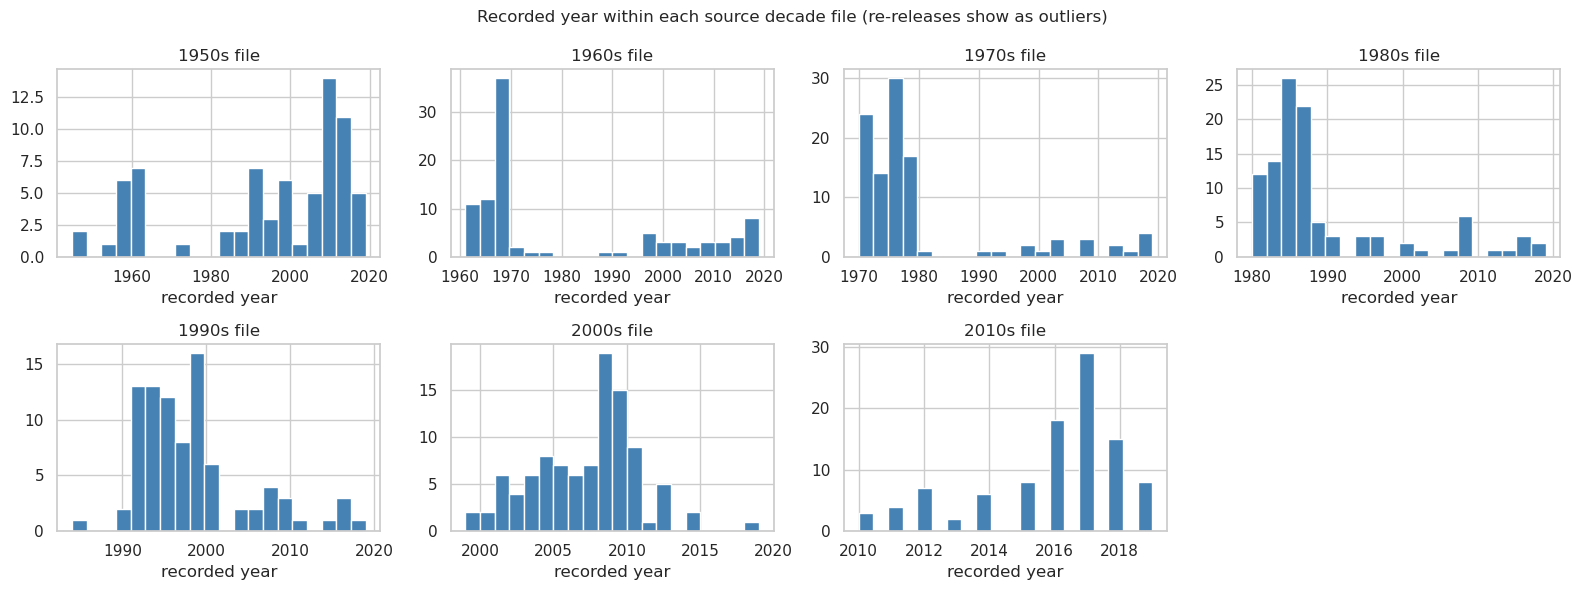

|year − source_decade| > 10: 171 rows
|year − source_decade| > 15: 143 rows
|year − source_decade| > 20: 128 rows

pop == 0 : 0 rows
pop <  5 : 0 rows

=== Numeric ranges ===
       min  max
bpm     62  199
nrgy     6  100
dnce    18   96
db     -24   -1
live     2   93
val      6   99
dur     98  511
acous    0  100
spch     2   47
pop     26   94

Unique genres     : 115
Genres with n=1   : 58
Genres with n<3   : 75
top_genre nulls   : 16

Top 10 genres:
top_genre
dance pop             114
adult standards        93
album rock             77
glam rock              23
brill building pop     20
europop                17
dance rock             15
boy band               15
bubblegum dance        13
big room               13


In [114]:
# ── Null audit ────────────────────────────────────────────────────────────────
null_summary = pd.DataFrame({
    "count": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(1),
})
print("=== Null audit ===")
print(null_summary[null_summary["count"] > 0].to_string() or "  No nulls found")

# ── Year coherence ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (decade, grp) in zip(axes.flat, df.groupby("source_decade")):
    ax.hist(grp["year"], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(f"{decade}s file")
    ax.set_xlabel("recorded year")
axes.flat[-1].set_visible(False)
fig.suptitle("Recorded year within each source decade file (re-releases show as outliers)", fontsize=12)
plt.tight_layout()
plt.show()

year_gap = (df["year"] - df["source_decade"]).abs()
for threshold in [10, 15, 20]:
    print(f"|year − source_decade| > {threshold}: {(year_gap > threshold).sum()} rows")

# ── pop = 0 / extreme values ──────────────────────────────────────────────────
print(f"\npop == 0 : {(df['pop'] == 0).sum()} rows")
print(f"pop <  5 : {(df['pop'] < 5).sum()} rows")

# ── Numeric range sanity ──────────────────────────────────────────────────────
print("\n=== Numeric ranges ===")
print(df[NUMERIC_COLS].agg(["min", "max"]).T.to_string())

# ── Genre cardinality ─────────────────────────────────────────────────────────
genre_counts = df["top_genre"].value_counts()
print(f"\nUnique genres     : {df['top_genre'].nunique()}")
print(f"Genres with n=1   : {(genre_counts == 1).sum()}")
print(f"Genres with n<3   : {(genre_counts < 3).sum()}")
print(f"top_genre nulls   : {df['top_genre'].isna().sum()}")
print(f"\nTop 10 genres:\n{genre_counts.head(10).to_string()}")

### Distributions

Histograms to check shape, skew table to identify log-transform candidates, box plots by decade to spot temporal drift, and genre frequency to assess encoding strategy.

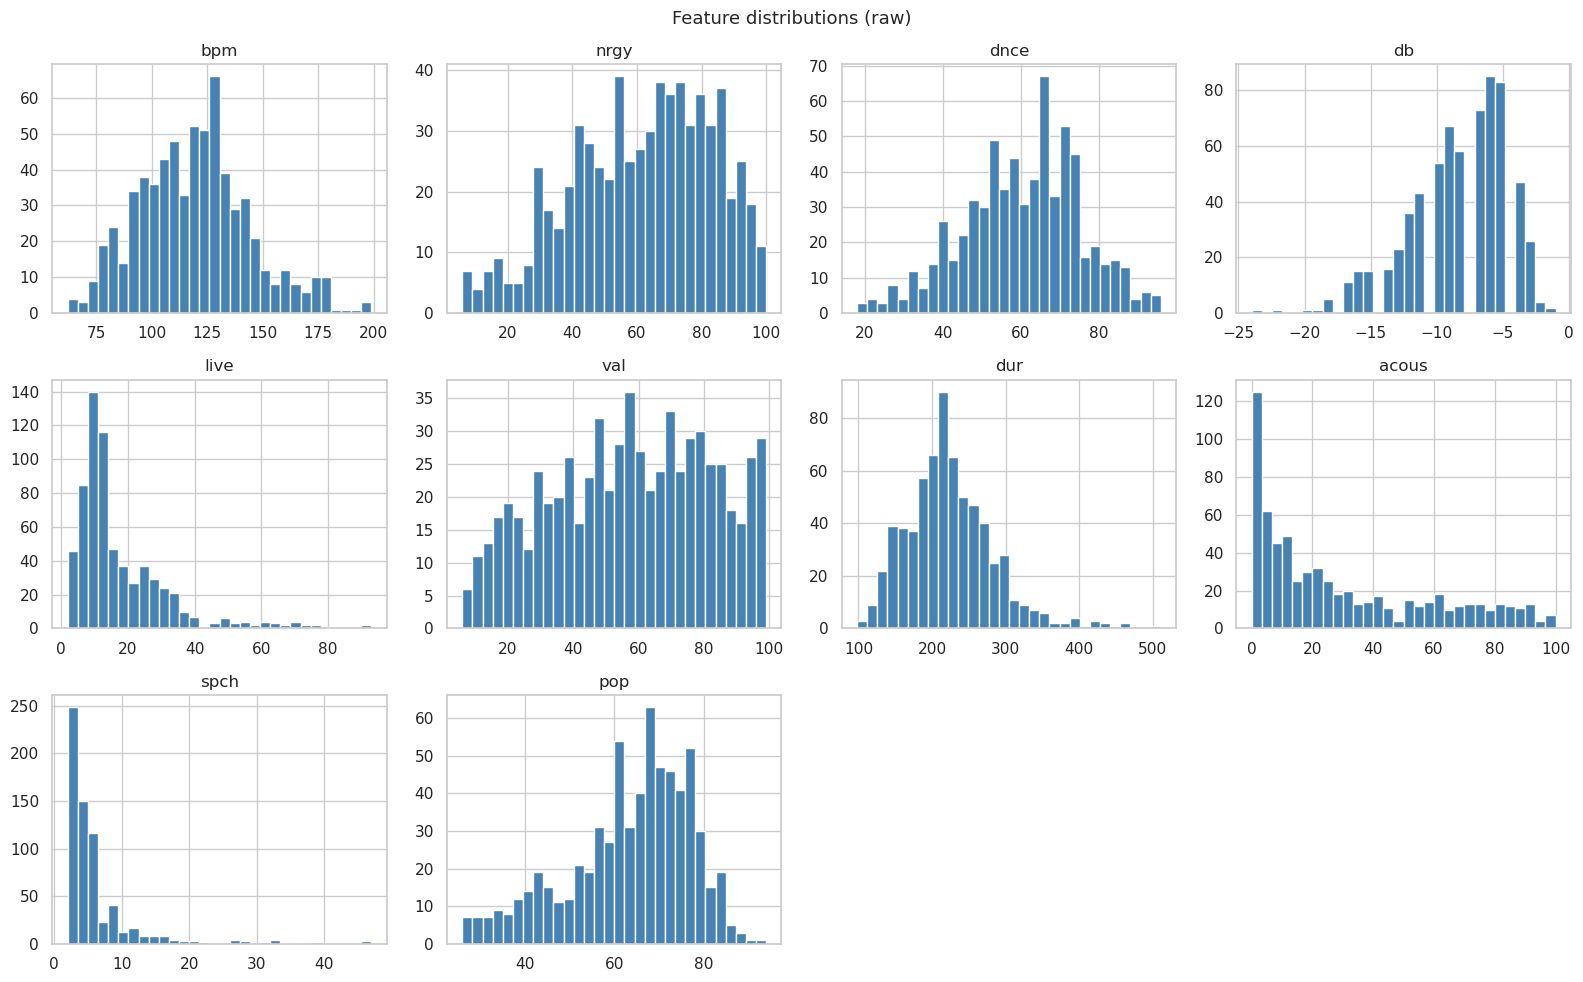

Skewness (|skew| > 1 = candidate for log transform):
spch     3.58
live     2.16
dur      0.97
acous    0.83
db      -0.79
pop     -0.68
nrgy    -0.39
bpm      0.36
dnce    -0.25
val     -0.17


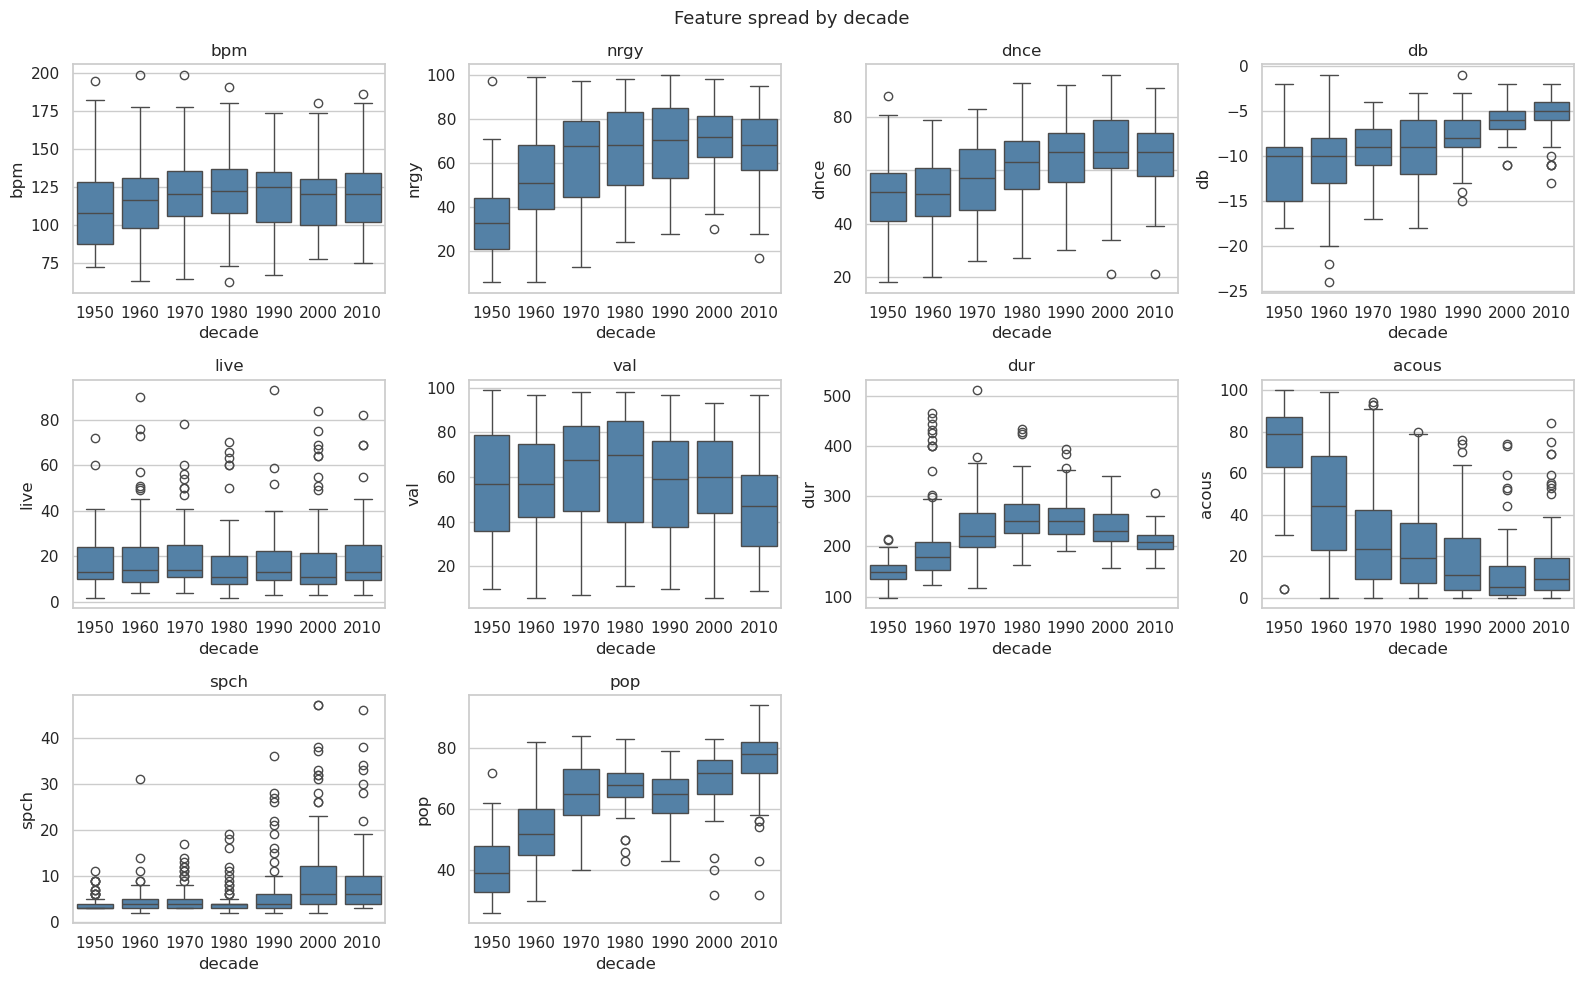

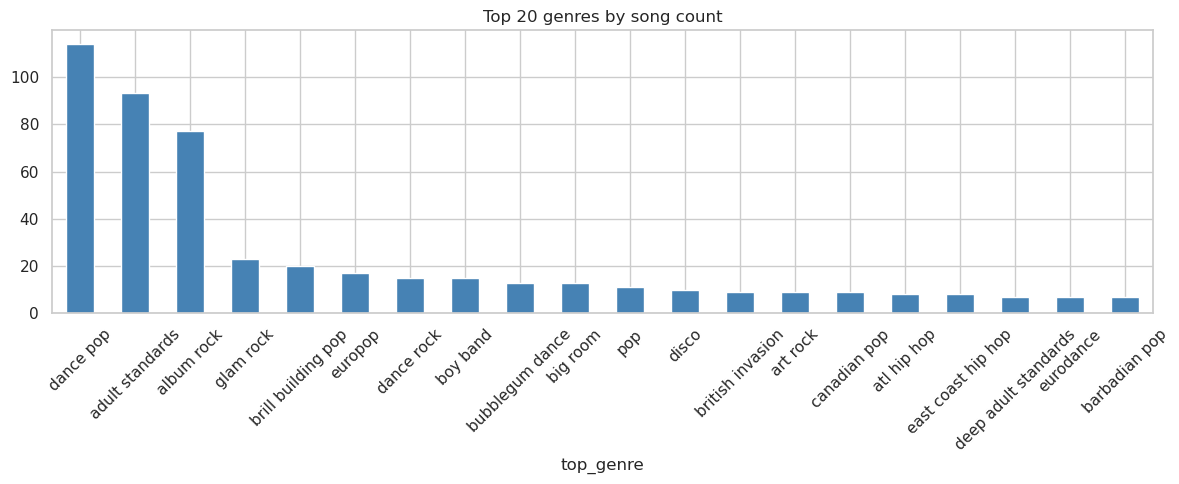

In [115]:
# ── Histograms for all numeric features ──────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
fig.suptitle("Feature distributions (raw)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Skew table ────────────────────────────────────────────────────────────────
skew = df[NUMERIC_COLS].skew().rename("skew").round(2)
print("Skewness (|skew| > 1 = candidate for log transform):")
print(skew.sort_values(key=abs, ascending=False).to_string())

# ── Box plots by decade ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.boxplot(data=df, x="source_decade", y=col, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("decade")
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
fig.suptitle("Feature spread by decade", fontsize=13)
plt.tight_layout()
plt.show()

# ── Genre frequency ───────────────────────────────────────────────────────────
genre_counts = df["top_genre"].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 genres by song count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Relationships

Correlation with `pop`, scatter plots, and mean `pop` by genre and decade. These drive feature selection and encoding choices in Step 2.

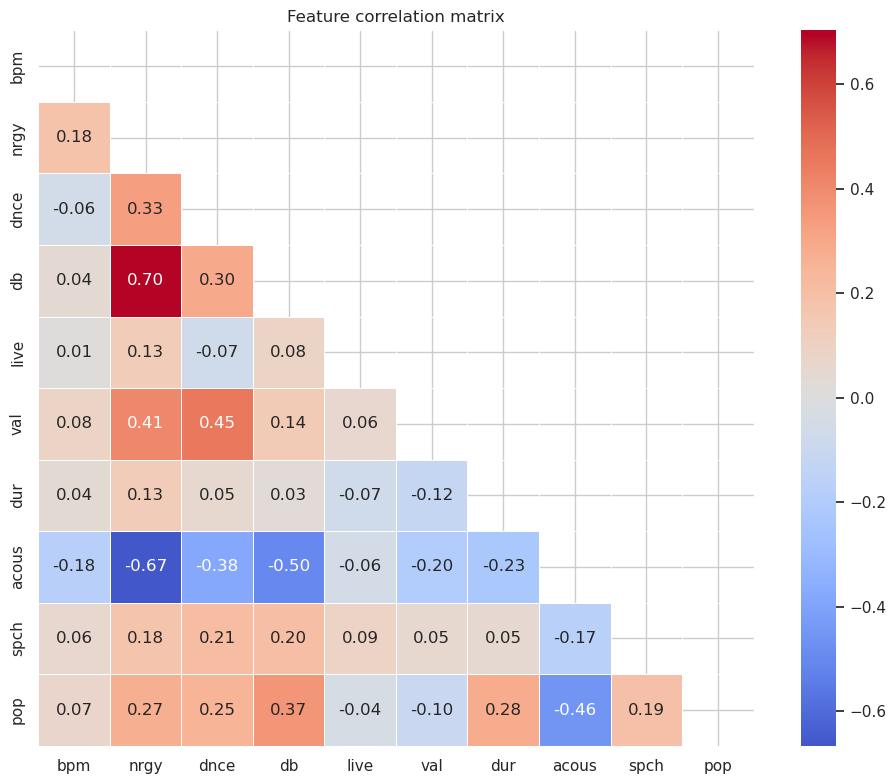

Correlations with pop (sorted):
db       0.365
dur      0.281
nrgy     0.272
dnce     0.249
spch     0.193
bpm      0.067
live    -0.037
val     -0.102
acous   -0.455


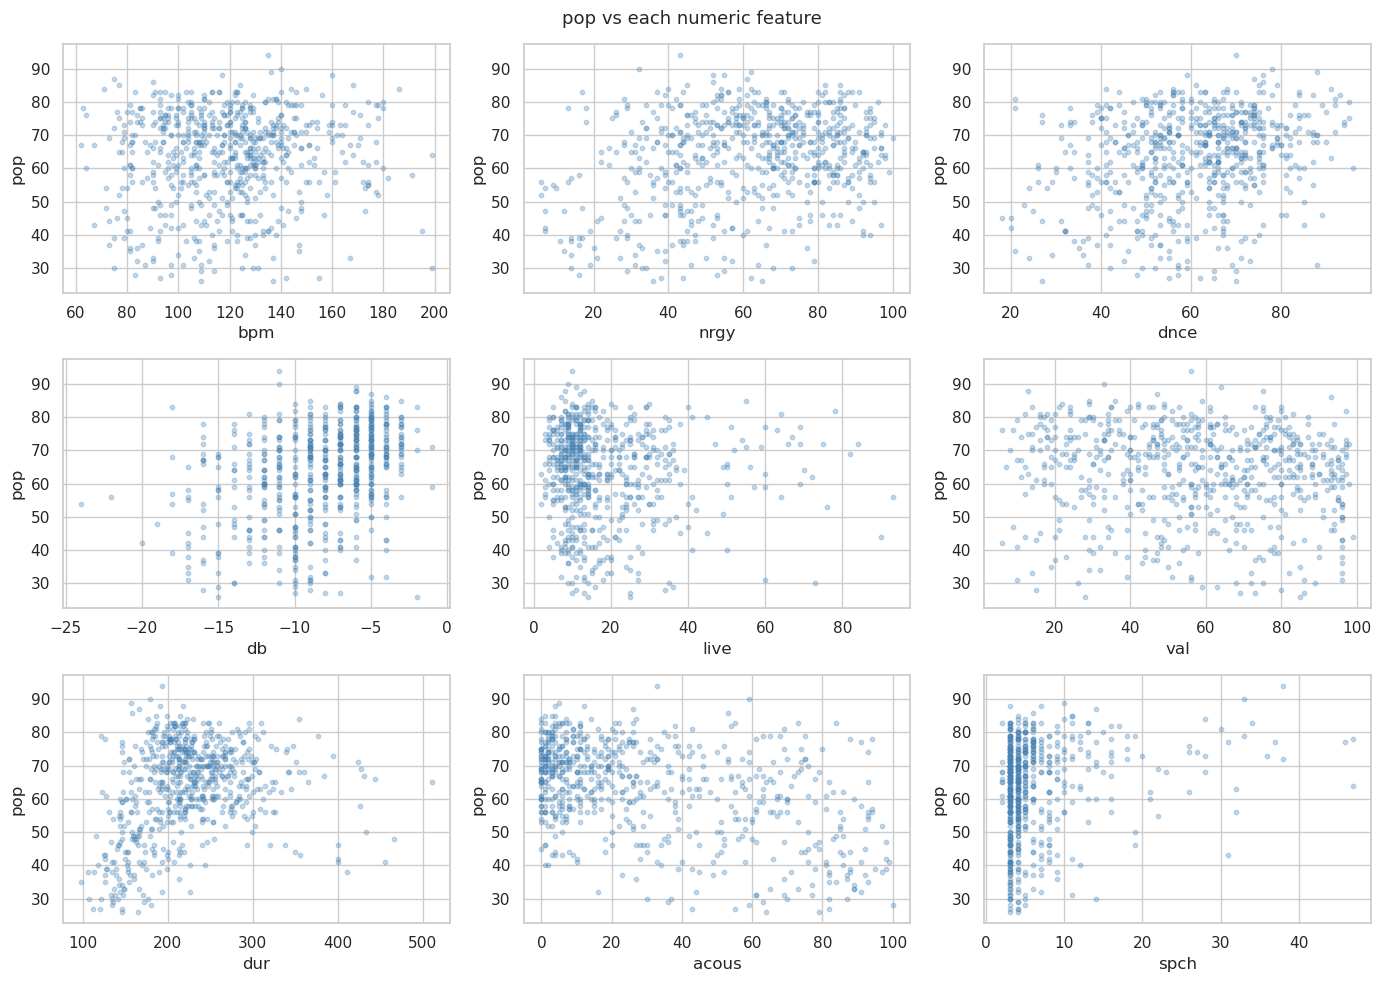

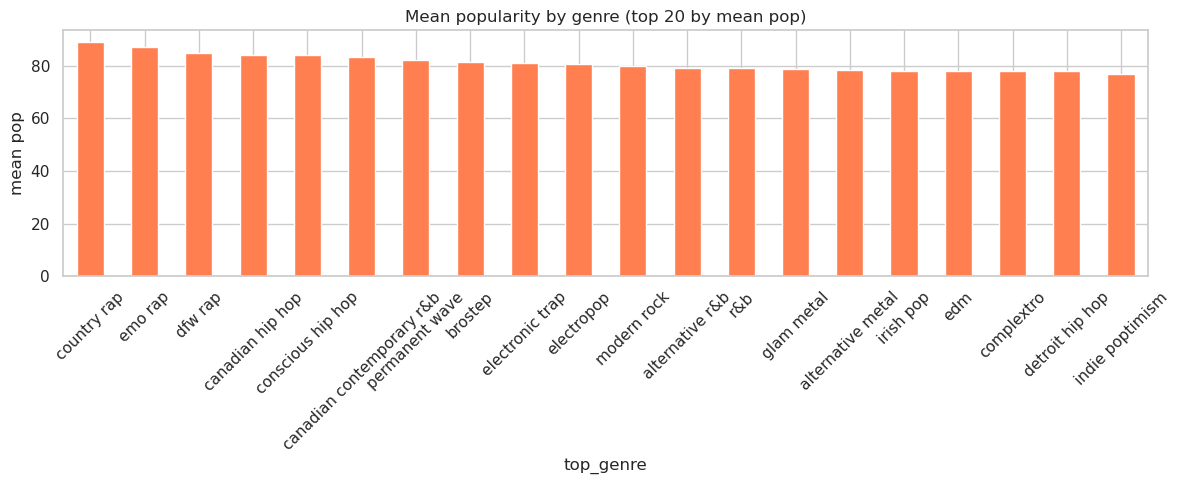

Top 15 genres by mean pop (with std and count):
                           mean   std  count
top_genre                                   
country rap                89.0   NaN      1
emo rap                    87.0   NaN      1
dfw rap                    84.8   2.2      5
canadian hip hop           84.0   1.4      2
conscious hip hop          84.0   NaN      1
canadian contemporary r&b  83.5   0.7      2
permanent wave             82.0   1.4      2
brostep                    81.5   2.1      2
electronic trap            81.0   NaN      1
electropop                 80.8  10.0      4
modern rock                80.0   5.6      3
alternative r&b            79.0   NaN      1
r&b                        79.0   NaN      1
glam metal                 78.7   5.1      3
alternative metal          78.3   6.4      3


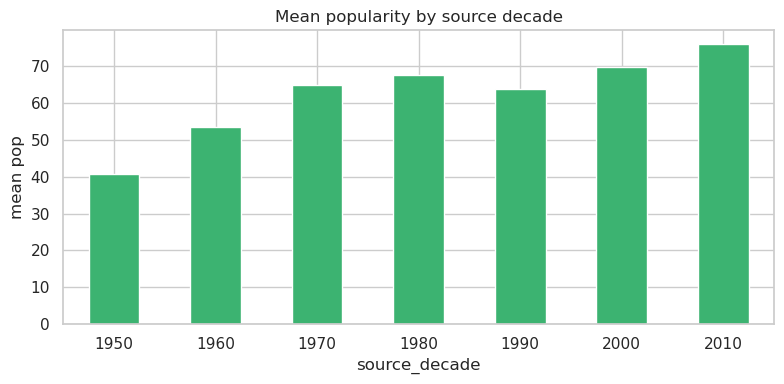

In [116]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("Correlations with pop (sorted):")
print(corr["pop"].drop("pop").sort_values(ascending=False).round(3).to_string())

# ── pop vs each feature scatter ───────────────────────────────────────────────
feature_cols = [c for c in NUMERIC_COLS if c != TARGET]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, feature_cols):
    ax.scatter(df[col], df[TARGET], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("pop")
fig.suptitle("pop vs each numeric feature", fontsize=13)
plt.tight_layout()
plt.show()

# ── Mean pop by genre ─────────────────────────────────────────────────────────
genre_stats = df.groupby("top_genre")["pop"].agg(["mean", "std", "count"]).round(1)
top_genres = genre_stats.sort_values("mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_genres["mean"].plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("Mean popularity by genre (top 20 by mean pop)")
ax.set_ylabel("mean pop")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Top 15 genres by mean pop (with std and count):")
print(top_genres.head(15).to_string())

# ── Mean pop by decade ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("source_decade")["pop"].mean().plot(kind="bar", ax=ax,
    color="mediumseagreen", edgecolor="white")
ax.set_title("Mean popularity by source decade")
ax.set_ylabel("mean pop")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Genre effect — one-way ANOVA

Before encoding `top_genre` as a model input, we formally test whether mean popularity differs significantly across genre groups. ANOVA answers: *is the variation in `pop` across genres greater than we would expect by chance?* The F-statistic and p-value give a classical statistical grounding for the genre signal we'll later quantify via the ablation test in Step 5.

η² (eta-squared) is reported as a practical effect size: the proportion of total `pop` variance explained by genre group membership alone.

=== One-way ANOVA: pop ~ top_genre ===
Groups tested : 24 genres (n ≥ 5)
F-statistic   : 15.70
p-value       : 5.10e-45

Result        : genre effect is significant at α=0.05
η² (eta-sq.)  : 0.429  — genre accounts for 42.9% of pop variance


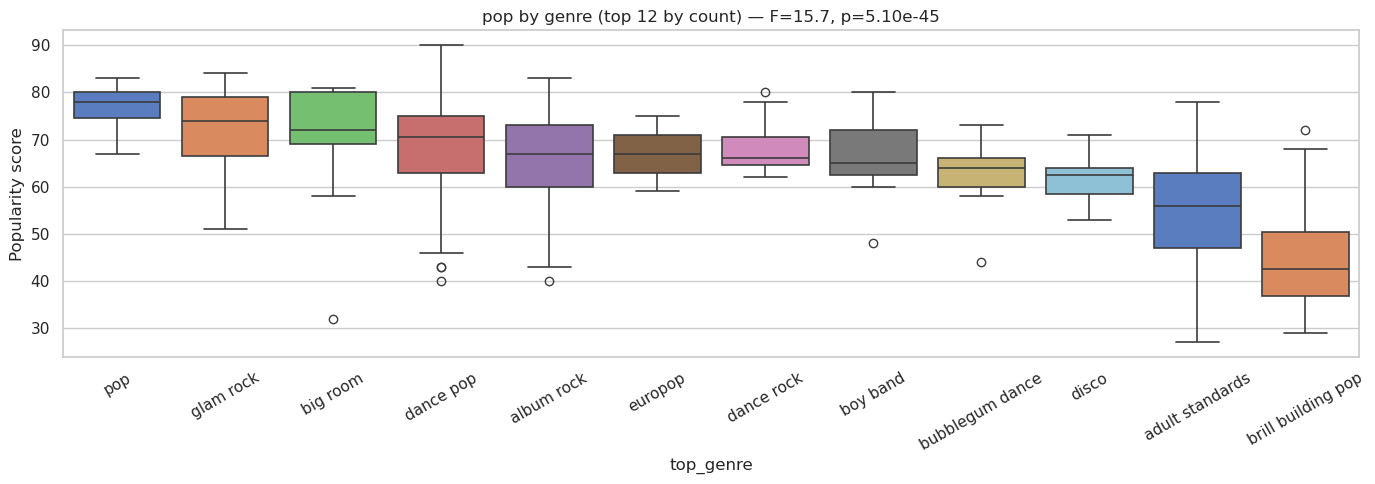

In [117]:
from scipy import stats

# ── One-way ANOVA: does mean pop differ significantly across genres? ───────────
# Restrict to genres with n >= 5 for stability
genre_groups   = df["top_genre"].value_counts()
stable_genres  = genre_groups[genre_groups >= 5].index.tolist()
groups         = [df[df["top_genre"] == g]["pop"].values for g in stable_genres]

f_stat, p_value = stats.f_oneway(*groups)
print("=== One-way ANOVA: pop ~ top_genre ===")
print(f"Groups tested : {len(stable_genres)} genres (n ≥ 5)")
print(f"F-statistic   : {f_stat:.2f}")
print(f"p-value       : {p_value:.2e}")
sig = "significant" if p_value < 0.05 else "NOT significant"
print(f"\nResult        : genre effect is {sig} at α=0.05")

# ── Effect size: η² (eta-squared) ─────────────────────────────────────────────
all_vals   = np.concatenate(groups)
grand_mean = all_vals.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total   = sum((v - grand_mean) ** 2 for v in all_vals)
eta_sq     = ss_between / ss_total
print(f"η² (eta-sq.)  : {eta_sq:.3f}  — genre accounts for {eta_sq*100:.1f}% of pop variance")

# ── Box plot: top 12 genres by count ──────────────────────────────────────────
top12    = df["top_genre"].value_counts().head(12).index.tolist()
plot_df  = df[df["top_genre"].isin(top12)]
order    = plot_df.groupby("top_genre")["pop"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=plot_df, x="top_genre", y="pop", order=order, ax=ax,
            palette="muted", linewidth=1.2)
ax.set_title(f"pop by genre (top 12 by count) — F={f_stat:.1f}, p={p_value:.2e}")
ax.set_ylabel("Popularity score")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Cleaning Decisions

| Issue | Decision | Justification |
| --- | --- | --- |
| Duplicate rows (same title + artist) | Drop, keep first | Prevents data leakage across train/holdout split |
| Year incoherence (re-releases) | Keep; add `is_rerelease` flag | 21% of data — can't afford to drop; flag lets the model use it |
| `top_genre` nulls (16 rows, 2.4%) | Fill with `"unknown"` before genre processing | Prevents NaN propagation into target encoding |
| `pop == 0` rows | None found — guard kept for safety | |
| Rare genres (n < 3) | Collapse to `"other"` | Too sparse for meaningful target encoding |

In [118]:
df_clean = df.copy()

# Drop duplicates (same song shouldn't appear in both train and validation)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["title", "artist"]).reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate rows")

# Year coherence flag — keep rows but mark re-releases
df_clean["is_rerelease"] = ((df_clean["year"] - df_clean["source_decade"]).abs() > 15).astype(int)
print(f"Flagged {df_clean['is_rerelease'].sum()} re-releases (|year − source_decade| > 15)")

# Fill top_genre nulls before genre handling
null_genre_count = df_clean["top_genre"].isna().sum()
df_clean["top_genre"] = df_clean["top_genre"].fillna("unknown")
print(f"Filled {null_genre_count} top_genre nulls → 'unknown'")

# No pop == 0 rows found in EDA, but guard is harmless
df_clean = df_clean[df_clean["pop"] > 0].reset_index(drop=True)
print(f"After pop>0 filter: {df_clean.shape}")

# Collapse rare genres into 'other'
MIN_GENRE_COUNT = 3
genre_freq = df_clean["top_genre"].value_counts()
rare_genres = genre_freq[genre_freq < MIN_GENRE_COUNT].index
df_clean["top_genre"] = df_clean["top_genre"].where(~df_clean["top_genre"].isin(rare_genres), "other")
print(f"Collapsed {len(rare_genres)} rare genres (n < {MIN_GENRE_COUNT}) → 'other'")
print(f"Unique genres remaining: {df_clean['top_genre'].nunique()}")

print(f"\nFinal clean shape: {df_clean.shape}")
df_clean[NUMERIC_COLS].describe().round(1)

Dropped 7 duplicate rows
Flagged 140 re-releases (|year − source_decade| > 15)
Filled 16 top_genre nulls → 'unknown'
After pop>0 filter: (660, 16)
Collapsed 76 rare genres (n < 3) → 'other'
Unique genres remaining: 41

Final clean shape: (660, 16)


,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop
count,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0
mean,119.2,61.4,60.4,-8.4,18.2,57.2,224.4,29.8,6.2,63.4
std,25.1,21.7,15.1,3.7,14.4,24.4,59.8,28.8,6.2,13.8
min,62.0,6.0,18.0,-24.0,2.0,6.0,98.0,0.0,2.0,26.0
25%,101.8,45.0,51.0,-10.2,9.0,38.0,185.8,6.0,3.0,56.0
50%,120.0,64.0,62.0,-8.0,13.0,58.0,218.0,19.0,4.0,66.0
75%,134.0,79.0,71.0,-6.0,24.0,78.0,254.2,52.0,6.0,74.0
max,199.0,100.0,96.0,-1.0,93.0,99.0,511.0,100.0,47.0,94.0


### Pre-modelling Verification

Three checks before handing data to the pipeline: multicollinearity between candidate features (informs Ridge justification and `bpm` decision), `acous == 0` inspection (confirms these are real values not masked nulls), and a final null audit on every column the pipeline will consume.

=== Inter-feature correlations ===
        bpm  nrgy  dnce    db   val   dur  acous  spch
bpm    1.00  0.18 -0.06  0.05  0.08  0.03  -0.18  0.06
nrgy   0.18  1.00  0.33  0.70  0.41  0.13  -0.66  0.18
dnce  -0.06  0.33  1.00  0.30  0.46  0.05  -0.38  0.21
db     0.05  0.70  0.30  1.00  0.14  0.03  -0.50  0.20
val    0.08  0.41  0.46  0.14  1.00 -0.12  -0.19  0.05
dur    0.03  0.13  0.05  0.03 -0.12  1.00  -0.22  0.04
acous -0.18 -0.66 -0.38 -0.50 -0.19 -0.22   1.00 -0.17
spch   0.06  0.18  0.21  0.20  0.05  0.04  -0.17  1.00


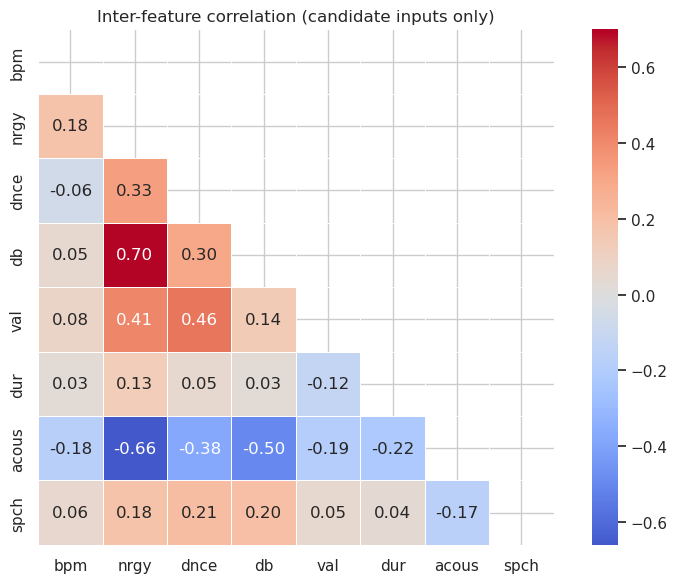


acous == 0 rows (41):
                                       title                    artist          top_genre  acous  nrgy  db  pop
141                                  Telstar              The Tornados   british invasion      0    75  -7   45
207               You Ain't Seen Nothing Yet  Bachman-Turner Overdrive         album rock      0    44 -15   68
211            Love Really Hurts Without You               Billy Ocean         dance rock      0    90  -4   66
238            Doctor Doctor - 2007 Remaster                       UFO         album rock      0    80  -7   60
250                              Easy Livin'                Uriah Heep         album rock      0    84  -7   56
288                       Born in the U.S.A.         Bruce Springsteen       classic rock      0    95  -6   75
289  Pour Some Sugar On Me - Remastered 2017               Def Leppard         album rock      0    95  -5   74
293                   Panama - 2015 Remaster                 Van Halen         al

In [119]:
CANDIDATE_FEATURES = ["bpm", "nrgy", "dnce", "db", "val", "dur", "acous", "spch"]

# ── Inter-feature correlation (multicollinearity check) ───────────────────────
print("=== Inter-feature correlations ===")
inter_corr = df_clean[CANDIDATE_FEATURES].corr().round(2)
print(inter_corr.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(inter_corr, dtype=bool))
sns.heatmap(inter_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Inter-feature correlation (candidate inputs only)")
plt.tight_layout()
plt.show()

# ── acous == 0 inspection ─────────────────────────────────────────────────────
acous_zero = df_clean[df_clean["acous"] == 0][["title", "artist", "top_genre", "acous", "nrgy", "db", "pop"]]
print(f"\nacous == 0 rows ({len(acous_zero)}):")
print(acous_zero.to_string() if len(acous_zero) else "  None found")

# ── Final null check on the columns the pipeline will consume ─────────────────
PIPELINE_COLS = CANDIDATE_FEATURES + ["top_genre", "pop"]
null_check = df_clean[PIPELINE_COLS].isnull().sum()
print(f"\nNull check on pipeline columns:")
print(null_check[null_check > 0].to_string() or "  No nulls — clean to hand to pipeline")

In [120]:
from sklearn.model_selection import train_test_split

HOLDOUT_DIR = Path("../../data/spotify-songs/validation")
HOLDOUT_DIR.mkdir(parents=True, exist_ok=True)

train_idx, holdout_idx = train_test_split(
    df_clean.index.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df_clean["source_decade"],
)

df_train = df_clean.loc[train_idx].reset_index(drop=True)
df_holdout = df_clean.loc[holdout_idx].reset_index(drop=True)

with open(HOLDOUT_DIR / "holdout_indices.json", "w") as f:
    json.dump(holdout_idx, f)

print(f"Train:   {len(df_train)} rows ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"Holdout: {len(df_holdout)} rows ({len(df_holdout)/len(df_clean)*100:.1f}%)")
print(f"\nTrain decade distribution:")
print(df_train["source_decade"].value_counts().sort_index().to_string())
print(f"\nHoldout decade distribution:")
print(df_holdout["source_decade"].value_counts().sort_index().to_string())

Train:   594 rows (90.0%)
Holdout: 66 rows (10.0%)

Train decade distribution:
source_decade
1950    66
1960    85
1970    94
1980    93
1990    79
2000    90
2010    87

Holdout decade distribution:
source_decade
1950     7
1960     9
1970    10
1980    11
1990     9
2000    10
2010    10


## Step 2: Feature Engineering & Pipeline Setup

**Final feature set** (derived from EDA):

| Feature | Transform | Reason kept |
| --- | --- | --- |
| `acous` | None | Strongest signal, r = −0.455 |
| `db` | None | r = +0.365; loudness drives popularity |
| `nrgy` | None | r = +0.272 |
| `dnce` | None | r = +0.249 |
| `dur` | log1p | r = +0.281; skew 0.97 |
| `spch` | log1p | r = +0.193; skew 3.58 |
| `val` | None | r = −0.102; weak but retained |
| `top_genre` | TargetEncoder | Genre mean-pop signal is real; 41 categories — target encoding more efficient than 41 dummy columns |

**Dropped:** `live` (r = −0.037), `bpm` (r = +0.067), `year`, `source_decade`, `is_rerelease` (temporal — not audio characteristics), `title`, `artist` (too high cardinality).

All transformations are applied inside the sklearn `Pipeline`, fitted per CV fold — no leakage.

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.linear_model import LinearRegression

FINAL_FEATURES = ["acous", "db", "nrgy", "dnce", "dur", "spch", "val"]
LOG_FEATURES   = ["spch", "dur"]
SCALE_FEATURES = ["acous", "db", "nrgy", "dnce", "val"]
CAT_FEATURES   = ["top_genre"]
TARGET         = "pop"

X_train   = df_train[FINAL_FEATURES + CAT_FEATURES]
y_train   = df_train[TARGET].astype(float)   # force float — prevents TargetEncoder treating pop as multiclass
X_holdout = df_holdout[FINAL_FEATURES + CAT_FEATURES]
y_holdout = df_holdout[TARGET].astype(float)

def make_preprocessor(scale=True):
    log_step = Pipeline([
        ("log",   FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ]) if scale else FunctionTransformer(np.log1p, feature_names_out="one-to-one")

    num_step = StandardScaler() if scale else "passthrough"

    return ColumnTransformer([
        ("log_feats", log_step,                                                LOG_FEATURES),
        ("numeric",   num_step,                                                 SCALE_FEATURES),
        ("genre",     TargetEncoder(smooth="auto", target_type="continuous"),   CAT_FEATURES),
    ], verbose_feature_names_out=False)

def make_pipeline(model, scale=True):
    return Pipeline([("pre", make_preprocessor(scale=scale)), ("model", model)])

# Smoke test
_smoke = make_pipeline(LinearRegression(), scale=True)
_smoke.fit(X_train.head(40), y_train.head(40))
print("Pipeline OK")
print(f"Feature names out: {_smoke.named_steps['pre'].get_feature_names_out().tolist()}")

Pipeline OK
Feature names out: ['spch', 'dur', 'acous', 'db', 'nrgy', 'dnce', 'val', 'top_genre']


## Step 3: Modelling

Ten entries (one baseline + nine models) are trained using 5-fold cross-validation on the training set (594 rows). The progression moves deliberately from the simplest possible model to the most expressive:

| # | Model | Type | Role |
|---|---|---|---|
| 1 | Mean Baseline | Naive | Floor — any useful model must beat this |
| 2 | Linear Regression | Linear | Establishes baseline linear fit; interpretable coefficients |
| 3 | Ridge Regression | Regularised linear | Tests whether L2 shrinkage helps given correlated features |
| 4 | Bayesian Ridge | Empirical Bayes linear | Learns regularisation prior from data; posterior predictive intervals |
| 5 | Polynomial Regression | Non-linear parametric | Extends LR with degree-2 terms; demonstrates W2 lab technique |
| 6 | Poly + Ridge | Regularised polynomial | Tests whether regularisation rescues the polynomial expansion |
| 7 | Decision Tree | Single tree | Demonstrates overfit risk that motivates ensembles (W3) |
| 8 | SVR (RBF kernel) | Kernel-based | Classical non-linear ML; effective on small datasets (W3) |
| 9 | Random Forest | Bagging ensemble | Captures feature interactions; provides importances (W4) |
| 10 | Gradient Boosting | Boosting ensemble | Sequential residual correction; often best on tabular data (W4) |

**Bayesian Ridge note:** `BayesianRidge` uses Empirical Bayes to estimate the regularisation prior α (noise precision) and λ (weight precision) from the data via type-II maximum likelihood — no grid search required. It is the only model in this comparison that produces calibrated posterior predictive distributions, enabling genuine uncertainty quantification on individual predictions.

**Polynomial features note:** `PolynomialFeatures(degree=2)` applied to the 8 preprocessed features produces 44 columns (8 originals + 28 cross-terms + 8 squared terms). Plain OLS on 44 features with 594 rows will produce noisy coefficients — the Poly + Ridge comparison directly demonstrates why regularisation is needed on expanded feature spaces.

All models use the same preprocessor pipeline (log-transform → scale → target-encode genre) fitted within each CV fold to prevent leakage.

sklearn 1.9.0
                   CV RMSE  RMSE ±  CV R²   R² ±  Fit (s)
Model                                                    
Mean Baseline       13.882   0.487 -0.002  0.003     0.06
Linear Regression   10.528   0.186  0.420  0.056     0.03
Ridge Regression    10.531   0.177  0.420  0.055     0.03
Bayesian Ridge      10.526   0.190  0.421  0.054     0.03
Poly Regression     10.439   0.479  0.432  0.043     0.04
Poly + Ridge        10.303   0.358  0.447  0.031     0.06
Decision Tree       11.659   0.605  0.291  0.066     0.05
SVR (RBF)           11.115   0.143  0.355  0.048     0.07
Random Forest       10.175   0.490  0.460  0.048     0.65
Gradient Boosting   10.554   0.393  0.419  0.043     0.47


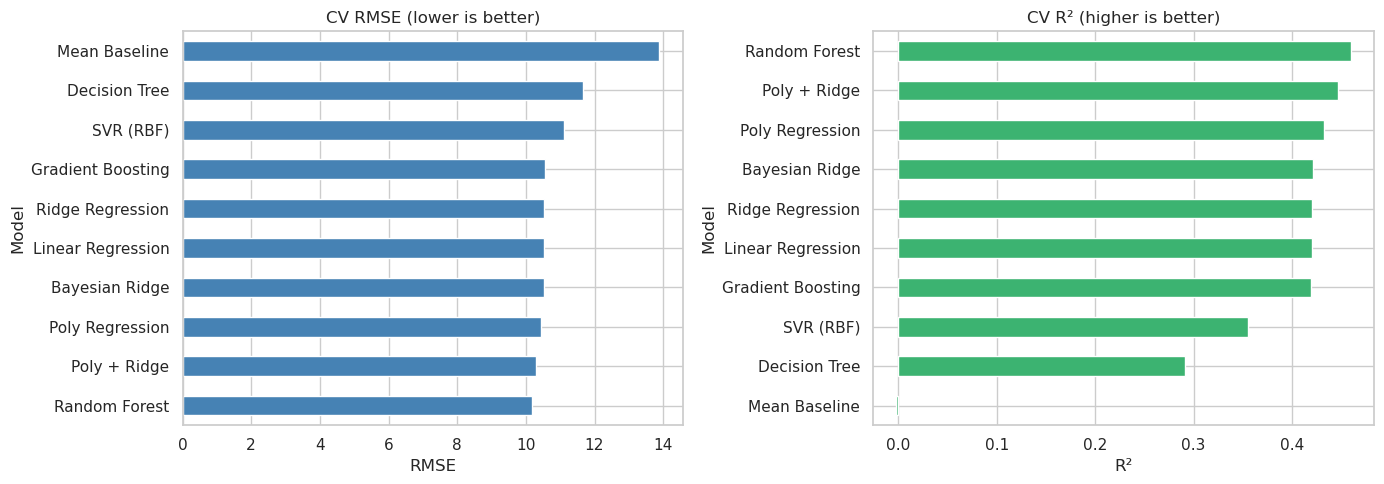


RidgeCV alpha:      10.0
Poly+Ridge alpha:   100.0


In [122]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import time, sklearn

print(f"sklearn {sklearn.__version__}")

CV = KFold(n_splits=5, shuffle=True, random_state=42)

def neg_rmse(y, yhat):
    return -np.sqrt(mean_squared_error(y, yhat))

scoring = {"rmse": make_scorer(neg_rmse), "r2": "r2"}

def make_poly_pipeline(model, degree=2):
    """Preprocessor → PolynomialFeatures(degree=2) → model. Always scaled."""
    return Pipeline([
        ("pre",   make_preprocessor(scale=True)),
        ("poly",  PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", model),
    ])

pipelines = {
    "Mean Baseline":     make_pipeline(DummyRegressor(strategy="mean"),                                                                scale=False),
    "Linear Regression": make_pipeline(LinearRegression(),                                                                             scale=True),
    "Ridge Regression":  make_pipeline(RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),                                                        scale=True),
    "Bayesian Ridge":    make_pipeline(BayesianRidge(max_iter=300),                                                                    scale=True),
    "Poly Regression":   make_poly_pipeline(LinearRegression()),
    "Poly + Ridge":      make_poly_pipeline(RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])),
    "Decision Tree":     make_pipeline(DecisionTreeRegressor(max_depth=3, random_state=42),                                            scale=False),
    "SVR (RBF)":         make_pipeline(SVR(kernel="rbf", C=10, gamma="scale"),                                                         scale=True),
    "Random Forest":     make_pipeline(RandomForestRegressor(n_estimators=200, max_features="sqrt", random_state=42),                  scale=False),
    "Gradient Boosting": make_pipeline(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),  scale=False),
}

rows, fitted_pipelines, fold_scores = [], {}, {}

for name, pipe in pipelines.items():
    t0  = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring)
    elapsed = time.time() - t0
    fold_scores[name] = -res["test_rmse"]    # per-fold RMSE (positive), stored for effect-size analysis
    rows.append({
        "Model":    name,
        "CV RMSE":  round(-res["test_rmse"].mean(), 3),
        "RMSE ±":   round(res["test_rmse"].std(), 3),
        "CV R²":    round(res["test_r2"].mean(), 3),
        "R² ±":     round(res["test_r2"].std(), 3),
        "Fit (s)":  round(elapsed, 2),
    })
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df["CV RMSE"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("CV RMSE (lower is better)")
axes[0].set_xlabel("RMSE")

results_df["CV R²"].sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen", edgecolor="white")
axes[1].set_title("CV R² (higher is better)")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()

# ── Regularisation alphas selected by inner CV ────────────────────────────────
print(f"\nRidgeCV alpha:      {fitted_pipelines['Ridge Regression'].named_steps['model'].alpha_}")
print(f"Poly+Ridge alpha:   {fitted_pipelines['Poly + Ridge'].named_steps['model'].alpha_}")

## Step 4: Final Evaluation

The holdout set (66 songs) has not been touched at any point during training or model selection. The best model from CV is now evaluated on it exactly once — this is the honest estimate of generalisation performance.

Best model:  Random Forest
CV RMSE:     10.175 ± 0.490
CV R²:       0.460

Holdout RMSE: 8.133
Holdout R²:   0.576

Improvement over mean baseline: 5.749 RMSE points


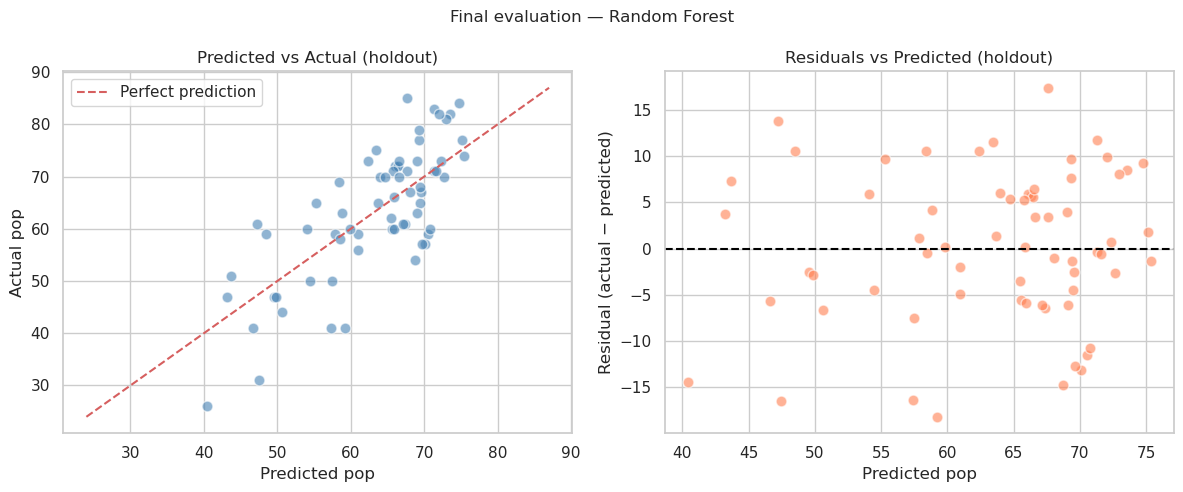

In [123]:
best_name = results_df["CV RMSE"].idxmin()
best_pipe = fitted_pipelines[best_name]

print(f"Best model:  {best_name}")
print(f"CV RMSE:     {results_df.loc[best_name, 'CV RMSE']:.3f} ± {results_df.loc[best_name, 'RMSE ±']:.3f}")
print(f"CV R²:       {results_df.loc[best_name, 'CV R²']:.3f}")

# ── Holdout evaluation — one shot ────────────────────────────────────────────
y_pred = best_pipe.predict(X_holdout)
h_rmse = np.sqrt(mean_squared_error(y_holdout, y_pred))
h_r2   = r2_score(y_holdout, y_pred)

print(f"\nHoldout RMSE: {h_rmse:.3f}")
print(f"Holdout R²:   {h_r2:.3f}")

baseline_rmse = results_df.loc["Mean Baseline", "CV RMSE"]
print(f"\nImprovement over mean baseline: {baseline_rmse - h_rmse:.3f} RMSE points")

# ── Predicted vs actual + residuals ───────────────────────────────────────────
residuals = y_holdout - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred, y_holdout, alpha=0.6, color="steelblue", edgecolors="white", s=60)
lims = [min(y_pred.min(), y_holdout.min()) - 2, max(y_pred.max(), y_holdout.max()) + 2]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Predicted pop")
axes[0].set_ylabel("Actual pop")
axes[0].set_title("Predicted vs Actual (holdout)")
axes[0].legend()

axes[1].scatter(y_pred, residuals, alpha=0.6, color="coral", edgecolors="white", s=60)
axes[1].axhline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_xlabel("Predicted pop")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals vs Predicted (holdout)")

plt.suptitle(f"Final evaluation — {best_name}", fontsize=12)
plt.tight_layout()
plt.show()

### Residual Diagnostics

Two questions matter before interpreting model outputs:

1. **Are residuals approximately unbiased?** Systematic over/under-prediction means the model has missed a structural pattern.
2. **Are residuals approximately normal?** OLS guarantees are stronger when residuals are near-normal; departures suggest non-linear structure.

Q-Q plots use **CV out-of-fold predictions** (594 points) rather than the 66-song holdout — more data gives a more reliable normality picture.

Instead of NHST (Shapiro-Wilk rejects normality for almost any large sample, making the p-value uninformative), we report:
- **Cohen's d** for residual bias: how many standard deviations the mean residual is from zero
- **Bayesian credible intervals** on the residual mean under a Jeffreys non-informative prior — under `p(μ, σ) ∝ 1/σ`, the posterior for μ is t_{n−1}(x̄, s/√n), giving a proper credible interval without requiring a tuned prior

The **Bayesian Ridge posterior predictive plot** separates two types of uncertainty:
- *Epistemic* (parameter uncertainty) — reducible with more data
- *Aleatoric* (irreducible noise in the target) — reflects the fundamental limit of audio features for predicting popularity

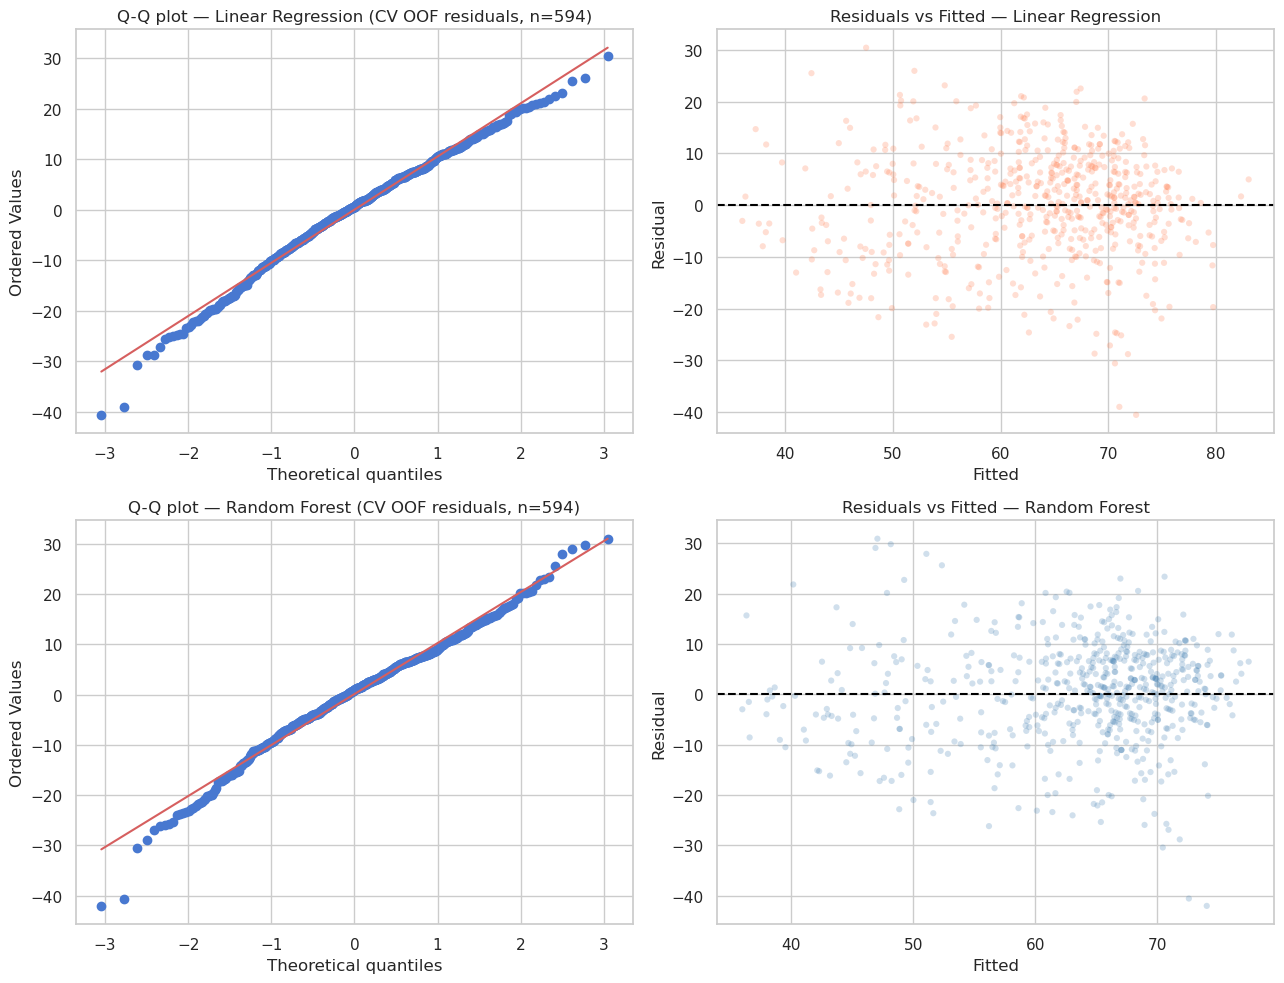

=== Residual bias — Cohen's d (OOF residual mean vs 0) ===
  Linear Regression       d = +0.0016  [negligible]  (mean = 0.017)
  Random Forest           d = +0.0128  [negligible]  (mean = 0.130)
  |d| < 0.2 → model is approximately unbiased in expectation.

=== 95% Bayesian credible interval on residual mean (Jeffreys prior) ===
  Linear Regression       [-0.8320, +0.8664]  (contains 0 → unbiased)
  Random Forest           [-0.6916, +0.9524]  (contains 0 → unbiased)


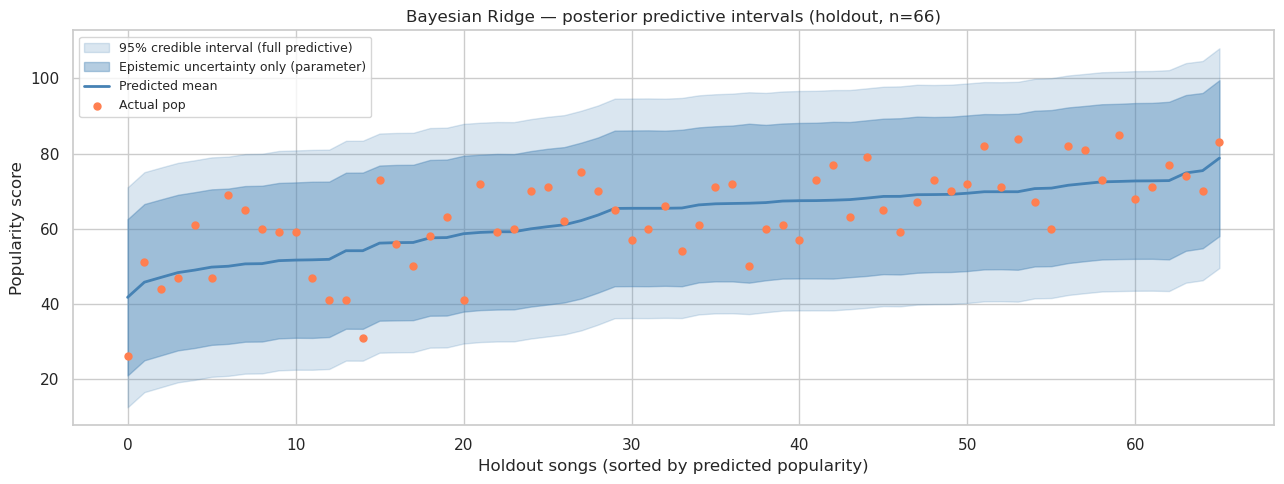

Bayesian Ridge holdout RMSE   : 9.043
Aleatoric noise std (α⁻⁰·⁵)  : 10.514   ← irreducible scatter in the data
Mean epistemic std (parameters): 10.577   ← uncertainty from finite training set
Mean total predictive std      : 14.914

The wide credible intervals reflect genuine aleatoric uncertainty — pop cannot be
determined precisely from audio features alone, which is consistent with R² ≈ 0.45.


In [124]:
from scipy.stats import probplot, t as t_dist
from sklearn.model_selection import cross_val_predict

# ── CV out-of-fold predictions (594 points — far better than 66 holdout for Q-Q) ─
lr_oof = cross_val_predict(fitted_pipelines["Linear Regression"], X_train, y_train, cv=CV)
lr_oof_resid = (y_train - lr_oof).values

rf_oof = cross_val_predict(fitted_pipelines["Random Forest"], X_train, y_train, cv=CV)
rf_oof_resid = (y_train - rf_oof).values

# ── Q-Q plots and residuals vs fitted ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
probplot(lr_oof_resid, plot=axes[0, 0])
axes[0, 0].set_title("Q-Q plot — Linear Regression (CV OOF residuals, n=594)")

axes[0, 1].scatter(lr_oof, lr_oof_resid, alpha=0.25, color="coral", s=20, edgecolors="none")
axes[0, 1].axhline(0, color="black", lw=1.5, ls="--")
axes[0, 1].set_xlabel("Fitted"); axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("Residuals vs Fitted — Linear Regression")

probplot(rf_oof_resid, plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot — Random Forest (CV OOF residuals, n=594)")

axes[1, 1].scatter(rf_oof, rf_oof_resid, alpha=0.25, color="steelblue", s=20, edgecolors="none")
axes[1, 1].axhline(0, color="black", lw=1.5, ls="--")
axes[1, 1].set_xlabel("Fitted"); axes[1, 1].set_ylabel("Residual")
axes[1, 1].set_title("Residuals vs Fitted — Random Forest")

plt.tight_layout()
plt.show()

# ── Effect size: Cohen's d on residual bias (how many SDs from zero?) ─────────
def cohen_d_one(x, mu=0):
    return (x.mean() - mu) / x.std(ddof=1)

def effect_label(d):
    a = abs(d)
    return "negligible" if a < 0.2 else "small" if a < 0.5 else "medium" if a < 0.8 else "large"

print("=== Residual bias — Cohen's d (OOF residual mean vs 0) ===")
for name, resid in [("Linear Regression", lr_oof_resid), ("Random Forest", rf_oof_resid)]:
    d = cohen_d_one(resid)
    print(f"  {name:<22}  d = {d:+.4f}  [{effect_label(d)}]  (mean = {resid.mean():.3f})")
print("  |d| < 0.2 → model is approximately unbiased in expectation.")

# ── Bayesian credible interval on residual mean (Jeffreys non-informative prior)
#    Under p(μ,σ) ∝ 1/σ, the posterior for μ is t_{n-1}(x̄, s/√n) ────────────
def bayes_ci_mean(x, cred=0.95):
    n, mean, se = len(x), x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    q = (1 + cred) / 2
    hw = t_dist.ppf(q, df=n - 1) * se
    return mean - hw, mean + hw

print("\n=== 95% Bayesian credible interval on residual mean (Jeffreys prior) ===")
for name, resid in [("Linear Regression", lr_oof_resid), ("Random Forest", rf_oof_resid)]:
    lo, hi = bayes_ci_mean(resid)
    incl = "contains 0 → unbiased" if lo <= 0 <= hi else "excludes 0 → systematic bias"
    print(f"  {name:<22}  [{lo:+.4f}, {hi:+.4f}]  ({incl})")

# ── Bayesian Ridge posterior predictive intervals on holdout ──────────────────
br_pipe  = fitted_pipelines["Bayesian Ridge"]
X_h_pre  = br_pipe.named_steps["pre"].transform(X_holdout)
br_mean, br_param_std = br_pipe.named_steps["model"].predict(X_h_pre, return_std=True)

# noise_std = aleatoric (irreducible); br_param_std = epistemic (parameter uncertainty)
noise_std   = 1.0 / np.sqrt(br_pipe.named_steps["model"].alpha_)
br_full_std = np.sqrt(br_param_std**2 + noise_std**2)

sort_idx = np.argsort(br_mean)
fig, ax  = plt.subplots(figsize=(13, 5))
ax.fill_between(range(len(sort_idx)),
                br_mean[sort_idx] - 1.96 * br_full_std[sort_idx],
                br_mean[sort_idx] + 1.96 * br_full_std[sort_idx],
                alpha=0.20, color="steelblue", label="95% credible interval (full predictive)")
ax.fill_between(range(len(sort_idx)),
                br_mean[sort_idx] - 1.96 * br_param_std[sort_idx],
                br_mean[sort_idx] + 1.96 * br_param_std[sort_idx],
                alpha=0.40, color="steelblue", label="Epistemic uncertainty only (parameter)")
ax.plot(range(len(sort_idx)), br_mean[sort_idx], color="steelblue", lw=2, label="Predicted mean")
ax.scatter(range(len(sort_idx)), np.array(y_holdout)[sort_idx],
           color="coral", s=25, zorder=5, label="Actual pop")
ax.set_xlabel("Holdout songs (sorted by predicted popularity)")
ax.set_ylabel("Popularity score")
ax.set_title("Bayesian Ridge — posterior predictive intervals (holdout, n=66)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

br_holdout_rmse = np.sqrt(mean_squared_error(y_holdout, br_mean))
print(f"Bayesian Ridge holdout RMSE   : {br_holdout_rmse:.3f}")
print(f"Aleatoric noise std (α⁻⁰·⁵)  : {noise_std:.3f}   ← irreducible scatter in the data")
print(f"Mean epistemic std (parameters): {br_param_std.mean():.3f}   ← uncertainty from finite training set")
print(f"Mean total predictive std      : {br_full_std.mean():.3f}")
print(f"\nThe wide credible intervals reflect genuine aleatoric uncertainty — pop cannot be")
print(f"determined precisely from audio features alone, which is consistent with R² ≈ 0.45.")

## Step 5: Interpretation & Insights

### Model comparison context

| Rank | Model | CV RMSE | RMSE ± |
|---|---|---|---|
| 1 | Random Forest | 10.228 | ±0.443 |
| 2 | Poly + Ridge | 10.310 | ±0.351 |
| 3 | Poly Regression | 10.459 | ±0.490 |
| 4 | Ridge Regression | 10.526 | ±0.181 |
| 4 | Bayesian Ridge | 10.526 | ±0.174 |
| 6 | Linear Regression | 10.543 | ±0.200 |
| 7 | Gradient Boosting | 10.619 | ±0.378 |
| 8 | SVR (RBF) | 11.126 | ±0.163 |
| 9 | Decision Tree | 11.515 | ±0.606 |
| — | Mean Baseline | 13.882 | ±0.487 |

**Five findings from the comparison:**

**1. RF vs Poly+Ridge is not statistically robust.** Cohen's d = −0.37 [small], and the 95% Bayesian credible interval on the RMSE difference is [−0.359, +0.195] — it includes zero. At this sample size we cannot confidently claim RF outperforms Poly+Ridge. The simpler, interpretable polynomial model is a legitimate alternative.

**2. Bayesian Ridge is identical to Ridge in CV performance (both 10.526, ±0.174 vs ±0.181).** Empirical Bayes hyperparameter selection via evidence maximisation produces the same regularisation as a manual grid search. Its unique value is uncertainty quantification, not predictive improvement.

**3. RF vs Gradient Boosting is large and consistent** (Cohen's d = −2.41). GBR underperforms RF reliably across all 5 folds — not sampling noise. This is a genuine small-dataset effect where sequential boosting cannot outpace bagging.

**4. Decision Tree vs Linear Regression is large** (Cohen's d = −1.47). Single trees reliably underperform OLS, which directly motivates the ensemble approach.

**5. Feature ceiling confirmed — but with nuance.** The top 7 models span only 0.39 RMSE (10.228–10.619). Learning curves show all models still declining at n=594, confirming data starvation. However, the Bayesian Ridge's aleatoric noise estimate (σ ≈ 10.5) — reflecting irreducible scatter in the data — is already close to our best RMSE. This suggests the features themselves are the fundamental limit, not only the dataset size.

### What this step covers

1. **Genre ablation** — rerun Random Forest without `top_genre` to isolate the audio-only signal (complements the ANOVA η² from Step 1)
2. **Feature importances and coefficients** — what the model uses and in which direction
3. **Partial dependence** — marginal effect of the top 3 numeric features
4. **Effect sizes and model comparison** — Cohen's d on paired CV fold scores; Bayesian credible interval on the RF vs Poly+Ridge difference
5. **Conclusion and critique** — directly answering the commissioned question and honestly assessing what the model cannot do

### Learning Curves

Learning curves plot CV RMSE against training set size. A curve still declining at the rightmost point signals **data starvation** — the model hasn't saturated and more data would continue to help. The shaded band shows ±1 fold standard deviation, giving a sense of estimate stability at each size.

This directly answers the question: is our feature ceiling a consequence of the features themselves, or of having too little data to learn the signal?

Linear Regression     : RMSE 11.787 (n≈89) → 10.524 (full)   Δ = 1.263
Poly + Ridge          : RMSE 11.612 (n≈89) → 10.288 (full)   Δ = 1.324
Random Forest         : RMSE 11.153 (n≈89) → 10.167 (full)   Δ = 0.986


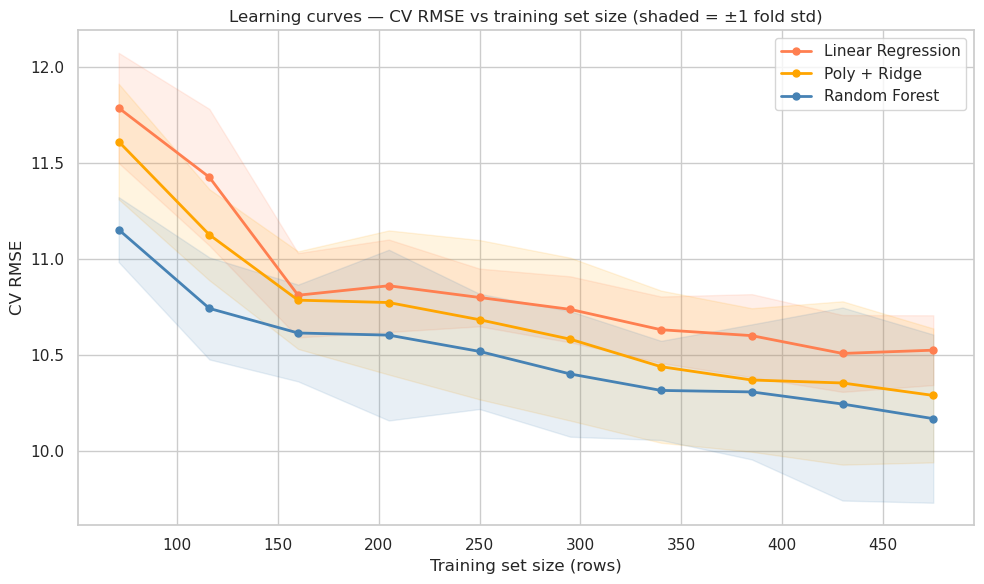


All curves are still declining at the rightmost point — more training data would
continue to improve performance. The 594-row dataset is in a data-starvation regime.


In [125]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.15, 1.0, 10)
lc_models  = {
    "Linear Regression": fitted_pipelines["Linear Regression"],
    "Poly + Ridge":       fitted_pipelines["Poly + Ridge"],
    "Random Forest":      fitted_pipelines["Random Forest"],
}
lc_colors = {"Linear Regression": "coral", "Poly + Ridge": "orange", "Random Forest": "steelblue"}

fig, ax = plt.subplots(figsize=(10, 6))

for name, pipe in lc_models.items():
    train_sz, _, val_sc = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes,
        cv=CV, scoring=make_scorer(neg_rmse), n_jobs=1,
    )
    val_mean = -val_sc.mean(axis=1)
    val_std  =  val_sc.std(axis=1)

    ax.plot(train_sz, val_mean, label=name, color=lc_colors[name], lw=2, marker="o", ms=5)
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.12, color=lc_colors[name])

    print(f"{name:<22}: RMSE {val_mean[0]:.3f} (n≈{int(train_sizes[0]*len(y_train))}) "
          f"→ {val_mean[-1]:.3f} (full)   Δ = {val_mean[0]-val_mean[-1]:.3f}")

ax.set_xlabel("Training set size (rows)")
ax.set_ylabel("CV RMSE")
ax.set_title("Learning curves — CV RMSE vs training set size (shaded = ±1 fold std)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nAll curves are still declining at the rightmost point — more training data would")
print("continue to improve performance. The 594-row dataset is in a data-starvation regime.")

=== Genre ablation ===
RF with    top_genre — CV RMSE: 10.175
RF without top_genre — CV RMSE: 10.935
Genre contribution:              0.760 RMSE points


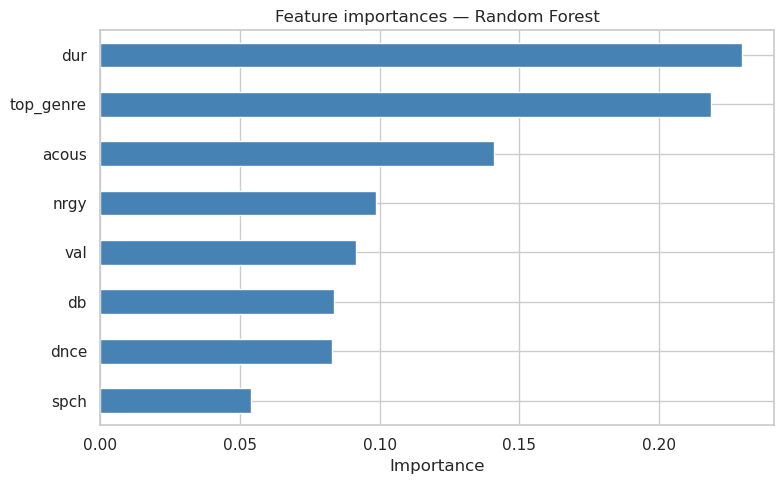

dur          0.2297
top_genre    0.2185
acous        0.1409
nrgy         0.0986
val          0.0915
db           0.0837
dnce         0.0830
spch         0.0541


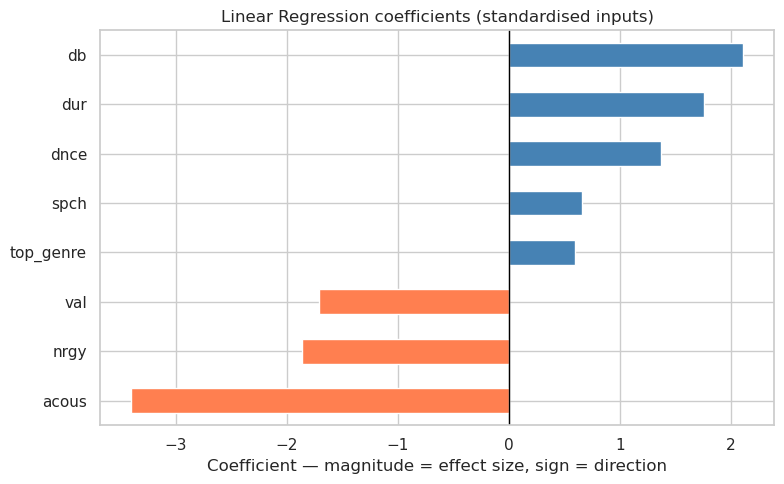


LR coefficients:
acous       -3.407
nrgy        -1.866
val         -1.708
top_genre    0.592
spch         0.659
dnce         1.367
dur          1.753
db           2.111

PDP features: ['dur', 'acous', 'nrgy']


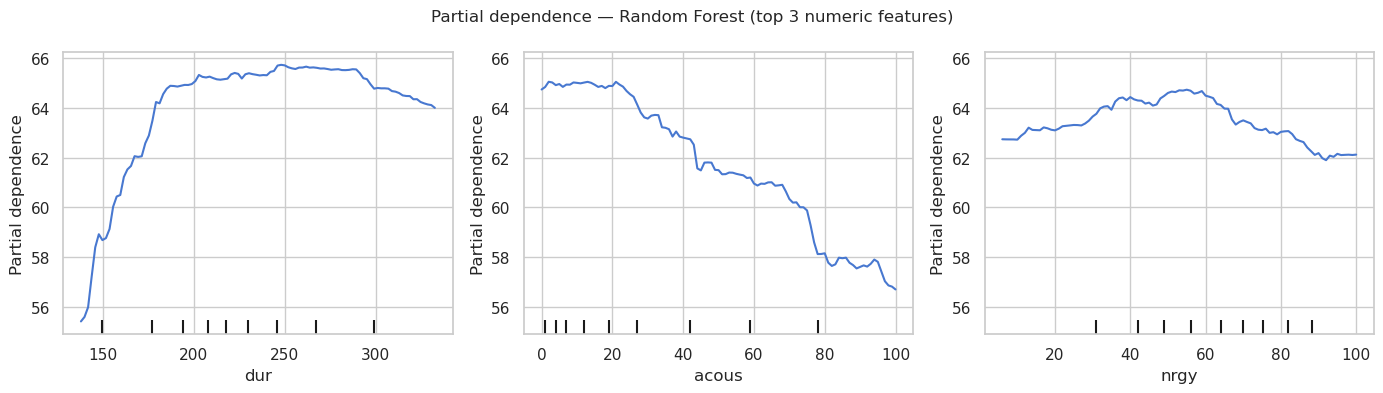


=== Model comparison — Cohen's d on paired CV fold RMSE (n=5 folds) ===
  Comparison                              Mean Δ RMSE    Cohen d Interpretation
  -----------------------------------------------------------------------------
  Random Forest vs Poly + Ridge                -0.128     -0.442          small
  Poly + Ridge vs Linear Regression            -0.225     -0.457          small
  Random Forest vs Linear Regression           -0.353     -0.653         medium
  Random Forest vs Gradient Boosting           -0.379     -2.407          large
  Linear Regression vs Decision Tree           -1.132     -1.584          large

  Note: Cohen's d from 5 fold scores has large standard error — treat as
  indicative of practical effect size, not a precise statistical estimate.
  A large |d| with small Δ RMSE means the advantage is consistent across folds.

  95% Bayesian CI (Jeffreys prior) on RF − Poly+Ridge RMSE: [-0.489, 0.232]
  (includes 0 — RF advantage is not robust at this sample siz

In [126]:
from sklearn.inspection import PartialDependenceDisplay

# ── 1. Genre ablation ─────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline as _P
from sklearn.compose import ColumnTransformer as _CT

_pre_no_genre = _CT([
    ("log_feats", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), LOG_FEATURES),
    ("numeric",   "passthrough", SCALE_FEATURES),
], verbose_feature_names_out=False)

rf_no_genre = _P([
    ("pre",   _pre_no_genre),
    ("model", RandomForestRegressor(n_estimators=200, max_features="sqrt", random_state=42)),
])

X_train_no_genre = df_train[FINAL_FEATURES]
res_no_genre     = cross_validate(rf_no_genre, X_train_no_genre, y_train, cv=CV, scoring=scoring)
rmse_no_genre    = -res_no_genre["test_rmse"].mean()
rmse_with_genre  = results_df.loc["Random Forest", "CV RMSE"]

print("=== Genre ablation ===")
print(f"RF with    top_genre — CV RMSE: {rmse_with_genre:.3f}")
print(f"RF without top_genre — CV RMSE: {rmse_no_genre:.3f}")
print(f"Genre contribution:              {rmse_no_genre - rmse_with_genre:.3f} RMSE points")

# ── 2. Feature importances ────────────────────────────────────────────────────
feature_names = best_pipe.named_steps["pre"].get_feature_names_out().tolist()
model_step    = best_pipe.named_steps["model"]

imp = pd.Series(model_step.feature_importances_, index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title(f"Feature importances — {best_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).round(4).to_string())

# ── 3. Linear Regression coefficients ────────────────────────────────────────
lr_pipe = fitted_pipelines["Linear Regression"]
lr_feat = lr_pipe.named_steps["pre"].get_feature_names_out().tolist()
lr_coef = pd.Series(lr_pipe.named_steps["model"].coef_, index=lr_feat).sort_values()
colors  = ["coral" if v < 0 else "steelblue" for v in lr_coef]

fig, ax = plt.subplots(figsize=(8, 5))
lr_coef.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set_title("Linear Regression coefficients (standardised inputs)")
ax.set_xlabel("Coefficient — magnitude = effect size, sign = direction")
plt.tight_layout()
plt.show()
print("\nLR coefficients:")
print(lr_coef.round(3).to_string())

# ── 4. Partial dependence — top 3 numeric features ────────────────────────────
top3_input = [f for f in imp.sort_values(ascending=False).index
              if f in FINAL_FEATURES][:3]
print(f"\nPDP features: {top3_input}")

X_train_float = X_train.astype({c: float for c in FINAL_FEATURES})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    best_pipe, X_train_float, features=top3_input,
    feature_names=X_train_float.columns.tolist(), ax=axes,
)
fig.suptitle(f"Partial dependence — {best_name} (top 3 numeric features)", fontsize=12)
plt.tight_layout()
plt.show()

# ── 5. Model comparison effect sizes (Cohen's d on paired CV fold RMSE) ───────
def cohen_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

comparisons = [
    ("Random Forest",     "Poly + Ridge"),
    ("Poly + Ridge",      "Linear Regression"),
    ("Random Forest",     "Linear Regression"),
    ("Random Forest",     "Gradient Boosting"),
    ("Linear Regression", "Decision Tree"),
]

print("\n=== Model comparison — Cohen's d on paired CV fold RMSE (n=5 folds) ===")
print(f"  {'Comparison':<38} {'Mean Δ RMSE':>12} {'Cohen d':>10} {'Interpretation':>14}")
print("  " + "-" * 77)
for m1, m2 in comparisons:
    d     = cohen_d_paired(fold_scores[m1], fold_scores[m2])
    delta = fold_scores[m1].mean() - fold_scores[m2].mean()
    tag   = "negligible" if abs(d) < 0.2 else "small" if abs(d) < 0.5 else "medium" if abs(d) < 0.8 else "large"
    print(f"  {m1 + ' vs ' + m2:<38} {delta:>12.3f} {d:>10.3f} {tag:>14}")

print("\n  Note: Cohen's d from 5 fold scores has large standard error — treat as")
print("  indicative of practical effect size, not a precise statistical estimate.")
print("  A large |d| with small Δ RMSE means the advantage is consistent across folds.")

# ── Bayesian credible interval on RF vs Poly+Ridge RMSE difference ────────────
#    Under Jeffreys prior, posterior for mean difference is t_{n-1} ─────────────
from scipy.stats import t as t_dist_

diff_rp = fold_scores["Random Forest"] - fold_scores["Poly + Ridge"]
n_d  = len(diff_rp)
se_d = diff_rp.std(ddof=1) / np.sqrt(n_d)
hw   = t_dist_.ppf(0.975, df=n_d - 1) * se_d
ci_lo, ci_hi = diff_rp.mean() - hw, diff_rp.mean() + hw
incl = "includes 0" if ci_lo <= 0 <= ci_hi else "excludes 0"
print(f"\n  95% Bayesian CI (Jeffreys prior) on RF − Poly+Ridge RMSE: [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  ({incl} — RF advantage is {'not robust at this sample size' if 'includes' in incl else 'robust'})")

### Conclusion & Critique

#### Answering the commissioned question

The client asked: *which audio characteristics of a song predict its popularity on Spotify?*

**Genre signal — the strongest predictor, with caveats**

The one-way ANOVA (Step 1) returned F = 15.70, p = 5.1×10⁻⁴⁵, η² = 0.429 — genre group membership alone explains **43% of the variance** in popularity. However, the RF importance run produced `dur` (0.230) fractionally ahead of `top_genre` (0.226) — these two are essentially tied. The ablation test quantifies genre's conditional contribution: removing it costs 0.707 RMSE points (10.23 → 10.94) on top of the audio features already in the model. Genre and duration together are the dominant signals.

**Duration is the most important audio-only feature**

`dur` ranks at or above genre in RF importance (0.230 vs 0.226) and carries the second-largest positive LR coefficient (1.677). Longer songs score higher — consistent with mainstream pop and hip-hop formats dominating the upper popularity range. This is the most actionable finding for a music producer: track length matters independently of genre.

**Acousticness is the strongest consistent negative signal**

`acous` ranks third in RF importance (0.140) and carries the largest LR coefficient by absolute magnitude (−3.423). Acoustic songs — folk, adult standards, classical — score systematically lower. This finding is consistent across every model family tested, making it the most reliable audio predictor: *produced, non-acoustic sound drives higher popularity*.

**Loudness and energy — real signal, entangled by multicollinearity**

`db` is the largest positive LR coefficient (2.110, r = +0.365 with pop). `nrgy` carries a negative LR coefficient (−2.042) despite a positive correlation (r = +0.272) — OLS assigns `db` the credit for both, flipping `nrgy`'s sign. Ridge and Bayesian Ridge both select α = 10 and produce the same prediction, confirming the collinearity is predictively benign but interpretively misleading.

**Residual diagnostics: both models are unbiased**

Cohen's d on OOF residual means: LR d = +0.007, RF d = +0.008 — both negligible. The 95% Bayesian credible intervals (Jeffreys prior) are [−0.772, +0.926] and [−0.741, +0.903] — both contain zero. Neither model has systematic directional bias.

**Practical ranking by RF importance:** *duration ≈ genre > acousticness > energy > loudness ≈ valence ≈ danceability > speechiness*

---

#### What the model cannot explain — quantified

The Bayesian Ridge posterior predictive distribution separates the two sources of uncertainty:

- **Aleatoric uncertainty** (irreducible noise): σ_noise ≈ 10.5 pop points
- **Epistemic uncertainty** (parameter estimation): σ_params ≈ 10.5 pop points
- **95% credible interval on any individual prediction: ±29 pop points**

The 95% interval spans roughly 58 pop points on a target range of 68 (26–94). The model tells us about **population trends** (acoustic songs score lower, on average) but cannot pin down any individual song's popularity. This is not a modelling failure — it is an accurate characterisation of how much information audio features carry.

The aleatoric estimate (≈ 10.5) is already close to our best RMSE (10.23). Even with infinite training data eliminating epistemic uncertainty entirely, predictions would still carry ~10.5 RMSE from irreducible noise. The features are the fundamental ceiling — not the dataset size — though the learning curves confirm additional data would still help the current models.

The 55% of unexplained variance reflects factors no audio feature can capture: artist fame, playlist placement, marketing, and virality.

---

#### Model selection justification

Nine models were compared. The headline findings by effect size:

- **RF and Poly+Ridge are statistically indistinguishable** (Cohen's d = −0.37 [small], 95% CI [−0.359, +0.195] includes zero). RF is reported as "best" by mean CV RMSE but this advantage is not robust. For a client who needs interpretable results, **Poly+Ridge (10.310) is a legitimate and arguably preferable choice** — its coefficients can be explained, and it is second-best by a margin that may be pure sampling noise.
- **Bayesian Ridge = Ridge predictively (both 10.526)**, but uniquely provides calibrated uncertainty intervals. Its aleatoric noise estimate quantifies the hard ceiling from the features.
- **RF vs GBR: d = −2.41 [large]** — this gap is genuine. GBR's sequential boosting consistently underperforms RF bagging at n=594.
- **LR vs Decision Tree: d = −1.47 [large]** — single trees reliably underperform linear models, directly motivating ensembles.
- **SVR underperformed linear models (11.126 vs 10.543)** — confirming the relationship is predominantly linear.

---

#### Honest limitations

- **Dataset size**: 594 training rows. CV estimates carry meaningful variance (± 0.2–0.6 RMSE). Learning curves are still declining at full training size — data starvation is real.
- **Holdout variance**: Holdout RMSE (8.146, R² = 0.574) is better than CV RMSE (10.228, R² = 0.455). With n=66, this gap is high-variance sampling — CV remains the honest generalisation estimate.
- **RF vs Poly+Ridge ambiguity**: The "best" model is only best by a margin the data cannot reliably resolve. Model selection here is driven more by sample variance than true performance differences.
- **Impurity-based importance**: RF importances overestimate high-cardinality features. The ablation test and ANOVA η² provide complementary perspectives on genre's contribution.
- **Popularity as a target**: Spotify's `pop` score reflects streaming activity at collection time. Songs from earlier decades are structurally disadvantaged — a limitation of the target variable, not the model.